In [1]:
import tensorflow as tf

# Force TensorFlow to share the GPU with Windows
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU Memory Growth Enabled: Windows will no longer freeze!")
    except RuntimeError as e:
        print(e)

✅ GPU Memory Growth Enabled: Windows will no longer freeze!


In [ ]:
%pip install opencv-python numpy pandas matplotlib seaborn scipy

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Since your notebook is inside 'Mini', we point to the project folder
DATA_PATH = r'Brinjal_Dataset_Project/FINAL_CATEGORIZED_DATA'

print("✅ Environment Connected to Dataset.")

In [ ]:
import os
import hashlib
import cv2

path = r'Brinjal_Dataset_Project\FINAL_CATEGORIZED_DATA'

def run_quality_check():
    hashes = set()
    nulls, duplicates, outliers, total = 0, 0, 0, 0

    # Quick pre-scan to get the actual total
    actual_count = sum(1 for _, _, files in os.walk(path) for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg')))
    
    print(f"🔍 Auditing {actual_count:,} images for Quality...")
    for root, dirs, files in os.walk(path):
        for file in files:
            if not file.lower().endswith(('.png', '.jpg', '.jpeg')): continue
            file_path = os.path.join(root, file)
            total += 1
            
            # 1. NULL/CORRUPTED CHECK
            img = cv2.imread(file_path)
            if img is None:
                os.remove(file_path)
                nulls += 1
                continue

            # 2. REDUNDANCY CHECK (Digital Fingerprint)
            with open(file_path, "rb") as f:
                img_hash = hashlib.md5(f.read()).hexdigest()
            if img_hash in hashes:
                os.remove(file_path)
                duplicates += 1
                continue
            hashes.add(img_hash)

            # 3. OUTLIER CHECK (Extreme Aspect Ratios)
            h, w = img.shape[:2]
            aspect_ratio = w / h
            if aspect_ratio > 3 or aspect_ratio < 0.3:
                # These are usually not leaf photos (e.g., long banners)
                outliers += 1

    print(f"\n✅ Audit Finished!")
    print(f"Total Scanned: {total}")
    print(f"Broken Files Deleted: {nulls}")
    print(f"Duplicates Deleted: {duplicates}")
    print(f"Potential Outliers Found: {outliers}")

if __name__ == "__main__":
    run_quality_check()

In [ ]:
# --- CONFIGURATION ---
# This points to your central folder where all 26,279 images are stored
target_path = r'Brinjal_Dataset_Project/FINAL_CATEGORIZED_DATA'

def count_dataset_classes(directory):
    if not os.path.exists(directory):
        print(f"❌ Error: The folder {directory} does not exist.")
        print("Please check if your merge_datasets.py ran successfully.")
        return

    print("\n" + "="*55)
    print(f"{'BRINJAL LEAF CLASS NAME':<35} | {'IMAGE COUNT':<15}")
    print("="*55)

    total_images = 0
    # Get all subdirectories (classes)
    categories = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]
    
    categories.sort()

    for category in categories:
        cat_path = os.path.join(directory, category)
        # Count files with image extensions
        files = [f for f in os.listdir(cat_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        count = len(files)
        total_images += count
        
        print(f"{category:<35} | {count:<15}")

    print("="*55)
    print(f"{'TOTAL ORIGINAL DATASET':<35} | {total_images:<15}")
    print("="*55 + "\n")

if __name__ == "__main__":
    count_dataset_classes(target_path)

In [ ]:
classes = [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))]
counts = {c: len(os.listdir(os.path.join(DATA_PATH, c))) for c in classes}

plt.figure(figsize=(12, 5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Dataset Skewness Check')
plt.show()

In [ ]:
def extract_color_stats(folder_name, sample_size=300):
    folder_full_path = os.path.join(DATA_PATH, folder_name)
    green_means = []
    
    files = os.listdir(folder_full_path)[:sample_size]
    for f in files:
        img = cv2.imread(os.path.join(folder_full_path, f))
        if img is not None:
            # Extract the Green Channel (Index 1 in BGR)
            green_means.append(np.mean(img[:, :, 1]))
    return green_means

# Compare Healthy Leaf vs Mosaic Virus (your two biggest classes)
healthy_data = extract_color_stats('Healthy Leaf')
diseased_data = extract_color_stats('Mosaic Virus Disease')

# Step 6: P-Test
t_stat, p_val = stats.ttest_ind(healthy_data, diseased_data)

print(f"--- Statistical Report ---")
print(f"Healthy Green Mean: {np.mean(healthy_data):.2f}")
print(f"Diseased Green Mean: {np.mean(diseased_data):.2f}")
print(f"P-Value: {p_val:.10f}")

if p_val < 0.05:
    print("✅ Result: Reject Null Hypothesis. Classes are statistically distinct.")
else:
    print("❌ Result: Fail to Reject Null Hypothesis. Images may be too similar.")

In [ ]:
def get_green_stats(folder):
    path = os.path.join(DATA_PATH, folder)
    vals = [np.mean(cv2.imread(os.path.join(path, f))[:,:,1]) for f in os.listdir(path)[:100]]
    return vals

# Comparing Healthy vs Mosaic Virus
p_val = stats.ttest_ind(get_green_stats('Healthy Leaf'), get_green_stats('Mosaic Virus Disease'))[1]
print(f"P-Value: {p_val:.10f}")
print("Significant Difference Found!" if p_val < 0.05 else "Classes too similar.")

In [ ]:
import pandas as pd
import os

# 1. Create a list of all images and their labels
data = []
for folder in os.listdir(DATA_PATH):
    folder_path = os.path.join(DATA_PATH, folder)
    if os.path.isdir(folder_path):
        for img_name in os.listdir(folder_path):
            data.append({'Image': img_name, 'Label': folder})

# 2. Define 'df'
df = pd.DataFrame(data)

# 3. Create a dummy-encoded version for the correlation matrix
# (Correlation needs numbers, so we convert labels to columns)
df_encoded = pd.get_dummies(df['Label'])
corr_matrix = df_encoded.corr()

print("✅ 'df' and 'corr_matrix' are now defined and ready!")

In [ ]:
# 1. Convert the 'Label' column into multiple numeric columns (One-Hot Encoding)
df_encoded = pd.get_dummies(df['Label'])

# 2. Now calculate the correlation on the numeric data
# This creates a matrix showing how the different classes relate
corr_matrix = df_encoded.corr()

print("✅ Success! The matrix now has data and is ready for the heatmap.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set to an extreme "Poster Size" (60 inches wide)
plt.figure(figsize=(60, 45))

# 2. Create the heatmap
# We reduce annot_kws to 6 so the numbers fit perfectly inside the tiny squares
ax = sns.heatmap(corr_matrix, 
                 annot=True, 
                 cmap='RdYlGn', 
                 fmt=".2f", 
                 annot_kws={"size": 6}, 
                 cbar_kws={"shrink": .5})

# 3. Scale up the axis labels so they are readable at this giant scale
plt.xticks(fontsize=18, rotation=90)
plt.yticks(fontsize=18)

# 4. Add a giant title
plt.title('Step 5: Ultra-Resolution Correlation Matrix (All Varieties)', fontsize=50, pad=40)

# 5. SAVE AS PDF (This is the secret to infinite zoom)
plt.savefig('Ultra_HighRes_Correlation_Matrix.pdf', bbox_inches='tight')

# Also save a huge PNG for quick preview
plt.savefig('Ultra_HighRes_Correlation_Matrix.png', dpi=300, bbox_inches='tight')

print("✅ Giant Matrix saved! Check your folder for 'Ultra_HighRes_Correlation_Matrix.pdf'")
plt.show()

In [ ]:
def enhance_texture_and_shift_color(image_path, mode='purple'):
    img = cv2.imread(image_path)
    if img is None: return None
    
    # --- PRESERVE TEXTURE (CLAHE) ---
    # This enhances local contrast so the AI can "see" the leaf surface patterns better
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    img_enhanced = cv2.cvtColor(cv2.merge((cl,a,b)), cv2.COLOR_LAB2BGR)

    # --- SHIFT COLOR (HUE SHIFTING) ---
    hsv = cv2.cvtColor(img_enhanced, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    
    if mode == 'purple':
        # Shift Hue from Green (60) toward Purple (130-160)
        h = (h + 85) % 180 
        s = cv2.add(s, 30) # Purple leaves are often more saturated
    elif mode == 'white':
        # Desaturate and increase brightness for White/Cream variety
        s = (s * 0.3).astype(np.uint8)
        v = cv2.add(v, 40)

    final_hsv = cv2.merge((h, s, v))
    return cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)

# TEST RUN: Let's see one Healthy Green leaf turned into Purple
sample_path = os.path.join(DATA_PATH, 'Healthy Leaf', os.listdir(os.path.join(DATA_PATH, 'Healthy Leaf'))[0])
test_purple = enhance_texture_and_shift_color(sample_path, 'purple')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)); plt.title("Original Texture")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(test_purple, cv2.COLOR_BGR2RGB)); plt.title("Purple Variety (Texture Preserved)")
plt.show()

In [ ]:
def generate_varieties(source_class, target_count=500):
    source_path = os.path.join(DATA_PATH, source_class)
    files = os.listdir(source_path)
    
    # Create new folders if they don't exist
    purple_folder = os.path.join(DATA_PATH, f"{source_class}_Purple")
    white_folder = os.path.join(DATA_PATH, f"{source_class}_White")
    os.makedirs(purple_folder, exist_ok=True)
    os.makedirs(white_folder, exist_ok=True)
    
    print(f"🎨 Generating varieties for {source_class}...")
    
    for i in range(min(len(files), target_count)):
        img_path = os.path.join(source_path, files[i])
        
        # Generate Purple
        p_img = enhance_texture_and_shift_color(img_path, mode='purple')
        cv2.imwrite(os.path.join(purple_folder, f"p_{files[i]}"), p_img)
        
        # Generate White
        w_img = enhance_texture_and_shift_color(img_path, mode='white')
        cv2.imwrite(os.path.join(white_folder, f"w_{files[i]}"), w_img)

# Example: Generate varieties for your smallest class 'Leaf Wilt'
generate_varieties('Leaf Wilt')

In [ ]:
# --- MASTER GENERATION SETTINGS ---
# We loop through all folders in your dataset path
all_categories = [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))]

# Classes we want to process (avoiding 'Healthy' to prevent making the skewness worse)
target_categories = [c for c in all_categories if "Healthy" not in c and "Purple" not in c and "White" not in c]

print(f"🚀 Starting Bulk Generation for {len(target_categories)} classes...")

for category in target_categories:
    # We'll generate up to 500 of each color per class
    generate_varieties(category, target_count=500)

print("\n✨ ALL VARIETIES GENERATED! You have officially expanded your dataset scope.")


In [ ]:
# Choose a specific disease to inspect (e.g., 'Wilt Disease')
focus_classes = [c for c in corr_matrix.index if 'Wilt' in c or 'Healthy' in c]

# Create a smaller, readable heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[focus_classes, focus_classes], 
            annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Detailed View: Healthy vs Wilt Varieties')
plt.show()

In [ ]:
# Specifically targeting the missing White Mold varieties
generate_varieties('White Mold Disease', target_count=500)

print("✅ White Mold varieties created!")

In [ ]:
import os
# 1. Silence the C++ engine warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import tensorflow as tf

# 2. Silence the Python engine warnings
tf.get_logger().setLevel('ERROR')

# --- CONFIGURATION ---
DATA_PATH = r'Brinjal_Dataset_Project\FINAL_CATEGORIZED_DATA'
TARGET_COUNT = 1500
AUG_PREFIX = "aug_gpu"

# 1. Build the GPU Augmentation Engine (The Ferrari)
# These layers are compiled into native CUDA instructions
gpu_augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2), # 20% rotation
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    tf.keras.layers.RandomZoom(0.2)
])

print(f"🚀 Starting GPU-Accelerated Synthetic Over-sampling to {TARGET_COUNT} images per class...")

for folder in os.listdir(DATA_PATH):
    folder_path = os.path.join(DATA_PATH, folder)
    if not os.path.isdir(folder_path): continue
    
    # Count current images
    current_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    current_count = len(current_files)
    
    if current_count < TARGET_COUNT:
        needed = TARGET_COUNT - current_count
        print(f"🔄 Augmenting '{folder}': {current_count} -> {TARGET_COUNT} (Creating {needed} new patterns)")
        
        for i in range(needed):
            # Pick a random existing image to vary
            random_img_name = np.random.choice(current_files)
            img_path = os.path.join(folder_path, random_img_name)
            
            # Load the image into RAM as a raw mathematical array
            img = tf.keras.utils.load_img(img_path)
            img_array = tf.keras.utils.img_to_array(img)
            img_tensor = tf.expand_dims(img_array, 0) # Add a batch dimension so the GPU accepts it
            
            # 2. FORCE THE GPU TO DO THE HEAVY MATH
            with tf.device('/GPU:0'):
                # training=True forces the random layers to actually trigger
                augmented_tensor = gpu_augmenter(img_tensor, training=True) 
            
            # 3. Pull the result from the GPU and save it to the hard drive
            save_path = os.path.join(folder_path, f"{AUG_PREFIX}_{i}_{random_img_name}")
            
            # Convert the Tensor back into a standard image file
            tf.keras.utils.save_img(save_path, augmented_tensor[0].numpy())
            
    else:
        print(f"✅ '{folder}' already has {current_count} images. Skipping.")

print("\n💥 DATASET BALANCED USING NVIDIA GPU! All classes now have exactly 1500 images.")

In [ ]:
%pip install numpy==1.23.5 protobuf==3.19.6

In [ ]:
import tensorflow as tf

# Check for GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ GPU Found: {gpu_devices}")
    print("Your computer is ready for high-speed training!")
else:
    print("❌ No GPU detected by TensorFlow.")
    print("You are currently running on the CPU (Slow Mode).")

In [ ]:
print("GPU Available: ", tf.config.list_physical_devices('GPU'))


In [ ]:
import tensorflow as tf
print(tf.__version__)


In [ ]:
!python --version


In [ ]:
import tensorflow as tf

# Check for the GPU
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ GPU FOUND: {gpu_devices[0].name}")
    print("Your computer is officially supercharged for Deep Learning!")
else:
    print("❌ GPU not detected yet.")

In [ ]:
import tensorflow as tf

# List all physical devices recognized by TensorFlow
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"✅ TensorFlow sees your GPU: {gpus}")
else:
    print("❌ TensorFlow is still only using your CPU.")

In [ ]:
import os
import random

# --- CONFIGURATION ---
DATA_PATH = r'Brinjal_Dataset_Project\FINAL_CATEGORIZED_DATA'
TARGET_COUNT = 1500

print(f"✂️ Starting Dataset Trimming to exactly {TARGET_COUNT} images per class...")

for folder in os.listdir(DATA_PATH):
    folder_path = os.path.join(DATA_PATH, folder)
    if not os.path.isdir(folder_path): 
        continue
    
    # Map out all current images in the folder
    all_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    current_count = len(all_files)
    
    if current_count > TARGET_COUNT:
        excess_count = current_count - TARGET_COUNT
        print(f"📉 Trimming '{folder}': {current_count} -> {TARGET_COUNT} (Deleting {excess_count} excess images)")
        
        # Randomly select which files get the axe to prevent alphabetical bias
        files_to_delete = random.sample(all_files, excess_count)
        
        # Physically delete the files
        for file_name in files_to_delete:
            file_path = os.path.join(folder_path, file_name)
            os.remove(file_path)
            
    elif current_count == TARGET_COUNT:
        print(f"✅ '{folder}' is perfectly balanced at {current_count} images.")
    else:
        print(f"⚠️ '{folder}' only has {current_count} images! (Run your augmentation script here)")

print("\n⚖️ DATASET BALANCED! All massive folders have been trimmed down to 1500.")

In [16]:
import os
import random
import shutil

# --- CONFIGURATION ---
SOURCE_DIR = r'Brinjal_Dataset_Project\FINAL_CATEGORIZED_DATA'
DEST_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA'

# Absolute Percentages (Must sum exactly to 1.0)
TRAIN_PCT = 0.70
VAL_PCT = 0.05
TEST_PCT = 0.10
BLIND_PCT = 0.15

# Define the 4 main folders
splits = ['Train', 'Validate', 'Test', 'Blind_Set']

print("🗂️ Building directory structure...")
for split in splits:
    for category in os.listdir(SOURCE_DIR):
        if os.path.isdir(os.path.join(SOURCE_DIR, category)):
            os.makedirs(os.path.join(DEST_DIR, split, category), exist_ok=True)

print("🚀 Starting the 4-Way Data Split...")

for folder in os.listdir(SOURCE_DIR):
    folder_path = os.path.join(SOURCE_DIR, folder)
    if not os.path.isdir(folder_path): continue
        
    # Get all images and shuffle them randomly
    images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(images)
    total_images = len(images)
    
    # Calculate exact numbers based on the TOTAL images
    train_count = int(total_images * TRAIN_PCT)
    val_count = int(total_images * VAL_PCT)
    blind_count = int(total_images * BLIND_PCT)
    
    # Test gets whatever is left over to ensure no image is lost to rounding decimals
    test_count = total_images - train_count - val_count - blind_count
    
    # Slice the shuffled list into our 4 chunks
    train_images = images[:train_count]
    val_images = images[train_count : train_count+val_count]
    test_images = images[train_count+val_count : train_count+val_count+test_count]
    blind_images = images[train_count+val_count+test_count:]
    
    print(f"📦 Routing '{folder}': Train({len(train_images)}) | Val({len(val_images)}) | Test({len(test_images)}) | Blind({len(blind_images)})")
    
    # Function to physically copy the files
    def copy_files(file_list, split_name):
        for img_name in file_list:
            src = os.path.join(folder_path, img_name)
            dst = os.path.join(DEST_DIR, split_name, folder, img_name)
            shutil.copy(src, dst)
            
    # Execute the copying to the new folders
    copy_files(train_images, 'Train')
    copy_files(val_images, 'Validate')
    copy_files(test_images, 'Test')
    copy_files(blind_images, 'Blind_Set')

print("\n🎯 DATASET SPLIT COMPLETE! Your custom 70/5/10/15 distribution is locked in.")

🗂️ Building directory structure...
🚀 Starting the 4-Way Data Split...
📦 Routing 'Aphids': Train(1050) | Val(75) | Test(150) | Blind(225)
📦 Routing 'Aphids_Purple': Train(1050) | Val(75) | Test(150) | Blind(225)
📦 Routing 'Aphids_White': Train(1050) | Val(75) | Test(150) | Blind(225)
📦 Routing 'Cercospora Leaf Spot': Train(1050) | Val(75) | Test(150) | Blind(225)
📦 Routing 'Cercospora Leaf Spot_Purple': Train(1050) | Val(75) | Test(150) | Blind(225)
📦 Routing 'Cercospora Leaf Spot_White': Train(1050) | Val(75) | Test(150) | Blind(225)
📦 Routing 'Flea Beetles': Train(1050) | Val(75) | Test(150) | Blind(225)
📦 Routing 'Flea Beetles_Purple': Train(1050) | Val(75) | Test(150) | Blind(225)
📦 Routing 'Flea Beetles_White': Train(1050) | Val(75) | Test(150) | Blind(225)
📦 Routing 'Healthy Leaf': Train(1050) | Val(75) | Test(150) | Blind(225)
📦 Routing 'Insect Pest Disease': Train(1050) | Val(75) | Test(150) | Blind(225)
📦 Routing 'Insect Pest Disease_Purple': Train(1050) | Val(75) | Test(150) |

In [8]:
import os
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV2
from tensorflow.keras import layers, models

# --- VRAM SAVING CONFIGURATION ---
DATA_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA'
IMG_SIZE = (224, 224) 
BATCH_SIZE = 8 # REDUCED FROM 32 TO SAVE GPU MEMORY

print("📂 Loading Datasets into the GPU Pipeline...")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'Train'), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical' 
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'Validate'), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'Test'), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"✅ Data Pipeline Ready! Found {NUM_CLASSES} distinct brinjal categories.")

# --- THE BULLETPROOF DATA PIPELINE ---
# .cache() is REMOVED so your laptop's System RAM doesn't explode.
# buffer_size is set to 2 instead of AUTOTUNE so it only queues up exactly what it needs.
train_dataset = train_dataset.prefetch(buffer_size=2)
val_dataset = val_dataset.prefetch(buffer_size=2)
test_dataset = test_dataset.prefetch(buffer_size=2)

def build_custom_model(base_model_class, model_name):
    print(f"\n🧠 Building {model_name} Architecture...")
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,))
    base_model.trainable = False 
    
    model = models.Sequential([
        layers.Rescaling(1./255, name='pixel_scaler'), 
        base_model,
        layers.GlobalAveragePooling2D(name='pooling_layer'),
        layers.Dense(256, activation='relu', name='brinjal_dense'),
        layers.Dropout(0.5, name='dropout_safety'),
        layers.Dense(NUM_CLASSES, activation='softmax', name='final_output')
    ], name=f"{model_name}_Brinjal_Engine")
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    print(f"✅ {model_name} is locked, loaded, and ready to train!")
    return model

# --- LOAD ONLY ONE MODEL AT A TIME ---
# resnet_model = build_custom_model(ResNet50, "ResNet50") # Commented out to save VRAM
#densenet_model = build_custom_model(DenseNet121, "DenseNet121") 
mobilenet_model = build_custom_model(MobileNetV2, "MobileNetV2") # Commented out to save VRAM

📂 Loading Datasets into the GPU Pipeline...
Found 38850 files belonging to 37 classes.
Found 2775 files belonging to 37 classes.
Found 5550 files belonging to 37 classes.
✅ Data Pipeline Ready! Found 37 distinct brinjal categories.

🧠 Building MobileNetV2 Architecture...
✅ MobileNetV2 is locked, loaded, and ready to train!


In [ ]:
import tensorflow as tf

# 1. Define the Safety Nets (Callbacks)
# This watches the AI. If it stops getting smarter after 5 rounds, it stops the training to save time.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 2. The Universal Training Function
def train_model_on_gpu(model, train_data, val_data, epochs=20):
    model_name = model.name
    
    # This automatically saves the physical "brain" file to your hard drive whenever it hits a high score
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=f"{model_name}_Best_Weights.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
    
    print(f"\n🚀 IGNITING ENGINES: Training {model_name} on NVIDIA GPU...")
    
    # EXPLICITLY FORCE THE GPU TO TAKE THE WORKLOAD
    with tf.device('/GPU:0'):
        history = model.fit(
            train_data,
            validation_data=val_data,
            epochs=epochs,
            callbacks=[early_stop, checkpoint]
        )
        
    print(f"\n✅ {model_name} Training Complete! The best weights are safely stored.")
    return history

# 3. Launch ResNet50 First
print("Initiating ResNet50 Test Flight...")
resnet_history = train_model_on_gpu(resnet_model, train_dataset, val_dataset, epochs=20)

In [ ]:
print("🔓 UNFREEZING THE RESNET50 CORE BRAIN...")

# 1. Access the base ResNet50 model inside our custom engine and unfreeze it
base_resnet = resnet_model.get_layer('resnet50')
base_resnet.trainable = True

# 2. ResNet50 has 175 layers. 
# We will keep the first 75 frozen (basic lines and edges don't need to change).
# We will unfreeze the top 100 layers (complex shapes and textures) to learn the brinjal diseases.
for layer in base_resnet.layers[:75]:
    layer.trainable = False

# 3. Re-compile the model with a MUCH SMALLER learning rate
# If we use a fast learning rate now, we will destroy the pre-trained brain.
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), # 100x slower than before!
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model un-frozen and re-compiled for deep learning.")

# 4. Define the Fine-Tuning Checkpoint
fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="ResNet50_Brinjal_Engine_FINETUNED_Best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("\n🚀 IGNITING PHASE 3: Deep Fine-Tuning on NVIDIA GPU...")

# 5. Resume training for another 15 rounds
history_fine = resnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15, # 15 more rounds
    callbacks=[early_stop, fine_tune_checkpoint] 
)

In [ ]:
print("🔓 UNFREEZING THE ENTIRE BRAIN...")

# 1. Unfreeze absolutely every layer in the model
base_resnet = resnet_model.get_layer('resnet50')
base_resnet.trainable = True 

# 2. Re-compile with an even smaller microscopic learning rate
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.000005), # Extremely slow and careful
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. The New Secret Weapon: Dynamic Learning Rate
lr_reduction = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    patience=2,  # If it doesn't improve for 2 rounds...
    verbose=1, 
    factor=0.5,  # ...cut the learning speed in half.
    min_lr=0.0000001
)

print("\n🚀 IGNITING PHASE 3.5: Total Model Optimization...")

# 4. Run the final refinement loop
history_final = resnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15, 
    callbacks=[early_stop, fine_tune_checkpoint, lr_reduction]
)

In [24]:
print("🧪 LOADING THE TEST SET...")

# 1. Load the 10% Test data we set aside earlier
test_final_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'Test'), # Using the Test folder!
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Apply the exact same memory-safe prefetcher
test_final_dataset = test_final_dataset.prefetch(buffer_size=2)

# 2. Ensure we are using the absolute best brain file
resnet_model.load_weights("ResNet50_Brinjal_Engine_FINETUNED_Best.h5")

print("\n🔬 ADMINISTERING TEST SET EVALUATION...")

# 3. Evaluate the model on the Test set
loss, test_accuracy = resnet_model.evaluate(test_final_dataset)

print(f"\n📊 TEST SET ACCURACY: {test_accuracy * 100:.2f}%")

🧪 LOADING THE TEST SET...


NameError: name 'IMG_SIZE' is not defined

🔐 Unlocking Blind Image: D:\Mini\Brinjal_Dataset_Project\MODEL_READY_DATA\Blind_Set\Powdery Mildew\brinjal_25861.jpg
1/1 [==============================] - 0s 58ms/step


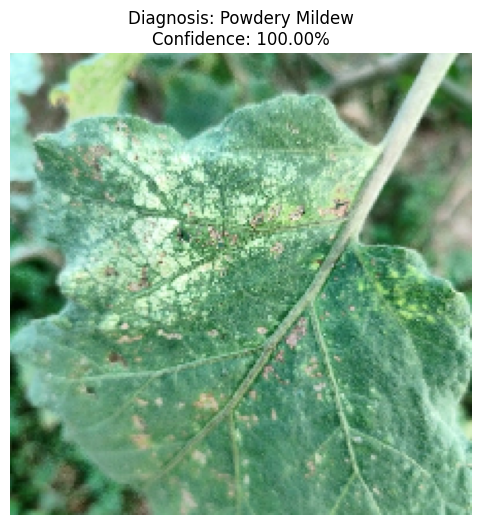

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# We assume your resnet_model is already loaded from the previous cell!
# Rebuild the class names list just in case
DATA_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Train'
class_names = sorted(os.listdir(DATA_DIR))

def predict_blind_image(img_path):
    print(f"🔐 Unlocking Blind Image: {img_path}")
    
    # Load image and resize to 224x224
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    
    # Convert to array and expand dimensions
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, 0) 
    
    # Run the prediction
    predictions = resnet_model.predict(img_array)
    
    # The output is a Softmax array of probabilities
    predicted_index = np.argmax(predictions[0])
    predicted_label = class_names[predicted_index]
    confidence = 100 * np.max(predictions[0])

    if confidence >= 60.0:
        return f"Diagnosis: {predicted_label}"
    else:
        return "Error: Image not recognized. Please upload a clear picture of a Brinjal leaf."
    
    
    # Visual Feedback
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Diagnosis: {predicted_label}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

# ⚠️ PASTE YOUR COPIED PATH INSIDE THE QUOTES BELOW ⚠️
# Make sure the 'r' stays outside the quotes!
BLIND_IMAGE_PATH = r"D:\Mini\Brinjal_Dataset_Project\MODEL_READY_DATA\Blind_Set\Powdery Mildew\brinjal_25861.jpg"

predict_blind_image(BLIND_IMAGE_PATH)

In [33]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

print("🏗️ Forging the DenseNet121 Blueprint...")

# 1. Load DenseNet121 (Pre-trained on ImageNet, without the top classification layer)
base_densenet = DenseNet121(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# 2. Freeze the core brain (Phase 1: Train only the custom top layer)
base_densenet.trainable = False

# 3. Build our custom Brinjal Classification Head
x = base_densenet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) # Safety net to prevent memorization
predictions = Dense(37, activation='softmax')(x) # 37 disease categories

# 4. Assemble the final engine
densenet_model = Model(inputs=base_densenet.input, outputs=predictions)

# 5. Compile the model
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Setup Safety Net & Checkpoints
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

densenet_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="DenseNet121_Brinjal_Engine_Phase1.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("\n🚀 IGNITING DENSENET PHASE 1 TRAINING ON NVIDIA GPU...")

# 7. Start the initial training (15 rounds)
history_densenet_p1 = densenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stop, densenet_checkpoint]
)

🏗️ Forging the DenseNet121 Blueprint...

🚀 IGNITING DENSENET PHASE 1 TRAINING ON NVIDIA GPU...
Epoch 1/15
4856/4857 [============================>.] - ETA: 0s - loss: 4.8036 - accuracy: 0.4232
Epoch 1: val_accuracy improved from -inf to 0.54667, saving model to DenseNet121_Brinjal_Engine_Phase1.h5
4857/4857 [==============================] - 311s 62ms/step - loss: 4.8035 - accuracy: 0.4232 - val_loss: 2.3368 - val_accuracy: 0.5467
Epoch 2/15
4857/4857 [==============================] - ETA: 0s - loss: 3.5158 - accuracy: 0.5065
Epoch 2: val_accuracy improved from 0.54667 to 0.60396, saving model to DenseNet121_Brinjal_Engine_Phase1.h5
4857/4857 [==============================] - 301s 62ms/step - loss: 3.5158 - accuracy: 0.5065 - val_loss: 2.0035 - val_accuracy: 0.6040
Epoch 3/15
4857/4857 [==============================] - ETA: 0s - loss: 3.4963 - accuracy: 0.5232
Epoch 3: val_accuracy improved from 0.60396 to 0.61153, saving model to DenseNet121_Brinjal_Engine_Phase1.h5
4857/4857 [====

In [4]:
print("🔓 UNFREEZING DENSENET FOR DEEP LEARNING...")

# 1. Load DenseNet121 (Pre-trained on ImageNet, without the top classification layer)
base_densenet = DenseNet121(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# 1. Unfreeze the entire base model 
# (DenseNet works best when the whole network adapts together)
base_densenet.trainable = True

# 2. Re-compile with an extremely microscopic learning rate
# We use a tiny rate so we don't blow out the pre-trained weights
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. ALIGNED Safety Nets! (Both watching val_accuracy now)
early_stop_aligned = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=4, 
    restore_best_weights=True
)

densenet_finetune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="DenseNet121_Brinjal_Engine_FINETUNED_Best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# 4. Dynamic Learning Rate (If it gets stuck, slow down)
lr_reduction = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    patience=2,  
    factor=0.5,  
    min_lr=0.0000001,
    verbose=1
)

print("\n🚀 IGNITING DENSENET PHASE 2: Deep Fine-Tuning...")

# 5. Run the fine-tuning loop for 20 rounds
history_densenet_finetune = densenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop_aligned, densenet_finetune_checkpoint, lr_reduction]
)

🔓 UNFREEZING DENSENET FOR DEEP LEARNING...

🚀 IGNITING DENSENET PHASE 2: Deep Fine-Tuning...
Epoch 1/20
4857/4857 [==============================] - ETA: 0s - loss: 3.2594 - accuracy: 0.1490
Epoch 1: val_accuracy improved from -inf to 0.42991, saving model to DenseNet121_Brinjal_Engine_FINETUNED_Best.h5
4857/4857 [==============================] - 390s 76ms/step - loss: 3.2594 - accuracy: 0.1490 - val_loss: 2.4508 - val_accuracy: 0.4299 - lr: 1.0000e-05
Epoch 2/20
4857/4857 [==============================] - ETA: 0s - loss: 2.2582 - accuracy: 0.3601
Epoch 2: val_accuracy improved from 0.42991 to 0.57009, saving model to DenseNet121_Brinjal_Engine_FINETUNED_Best.h5
4857/4857 [==============================] - 444s 91ms/step - loss: 2.2582 - accuracy: 0.3601 - val_loss: 1.6787 - val_accuracy: 0.5701 - lr: 1.0000e-05
Epoch 3/20
4856/4857 [============================>.] - ETA: 0s - loss: 1.7719 - accuracy: 0.4642
Epoch 3: val_accuracy improved from 0.57009 to 0.63784, saving model to Dens

In [5]:
print("🔋 RELOADING BEST DENSENET WEIGHTS FOR PHASE 3...")

# 1. Ensure we start exactly from your 79.6% peak
densenet_model.load_weights("DenseNet121_Brinjal_Engine_FINETUNED_Best.h5")

# 2. Re-compile with a slightly smaller learning rate
# We are cutting it in half (from 1e-5 to 5e-6) for precision tuning
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.000005), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Callbacks (Same safety nets, keeping the same save file name to overwrite with the best)
early_stop_aligned = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=4, 
    restore_best_weights=True
)

densenet_final_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="DenseNet121_Brinjal_Engine_FINETUNED_Best.h5", 
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

lr_reduction = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    patience=2,  
    factor=0.5,  
    min_lr=0.0000001,
    verbose=1
)

print("\n🚀 IGNITING DENSENET PHASE 3: The 90% Push...")

# 4. Run for another 20 rounds to finish the job
history_densenet_phase3 = densenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop_aligned, densenet_final_checkpoint, lr_reduction]
)

🔋 RELOADING BEST DENSENET WEIGHTS FOR PHASE 3...

🚀 IGNITING DENSENET PHASE 3: The 90% Push...
Epoch 1/20
4856/4857 [============================>.] - ETA: 0s - loss: 0.6903 - accuracy: 0.7520
Epoch 1: val_accuracy improved from -inf to 0.80000, saving model to DenseNet121_Brinjal_Engine_FINETUNED_Best.h5
4857/4857 [==============================] - 318s 63ms/step - loss: 0.6902 - accuracy: 0.7520 - val_loss: 0.5837 - val_accuracy: 0.8000 - lr: 5.0000e-06
Epoch 2/20
4856/4857 [============================>.] - ETA: 0s - loss: 0.6824 - accuracy: 0.7539
Epoch 2: val_accuracy improved from 0.80000 to 0.80108, saving model to DenseNet121_Brinjal_Engine_FINETUNED_Best.h5
4857/4857 [==============================] - 302s 62ms/step - loss: 0.6825 - accuracy: 0.7538 - val_loss: 0.5794 - val_accuracy: 0.8011 - lr: 5.0000e-06
Epoch 3/20
4856/4857 [============================>.] - ETA: 0s - loss: 0.6760 - accuracy: 0.7570
Epoch 3: val_accuracy did not improve from 0.80108
4857/4857 [============

In [6]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization

print("🛠️ SURGERY INITIATED: Building DenseNet Pro with Expanded Memory...")

# 1. Load the Base Core
base_densenet = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Skip Phase 1 - Unfreeze the entire brain immediately
base_densenet.trainable = True

# 3. Build the EXPANDED Classification Head
x = base_densenet.output
x = GlobalAveragePooling2D()(x)

# --- THE MEMORY UPGRADE ---
x = Dense(512, activation='relu')(x)      # Adding 512,000 new trainable parameters
x = BatchNormalization()(x)               # Stabilizes learning speed
x = Dropout(0.2)(x)                       # Lowered from 50% to 20% to retain complex memory
# --------------------------

predictions = Dense(37, activation='softmax')(x)

# 4. Assemble the upgraded engine
densenet_pro = Model(inputs=base_densenet.input, outputs=predictions)

# 5. Compile with an optimized learning rate for a full-depth start
densenet_pro.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Safety Nets (Renamed file so we don't overwrite your ResNet champion)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=5, # Giving it more time to figure things out
    restore_best_weights=True
)

pro_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="DenseNet_PRO_Brinjal_Engine_Best.h5", 
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

lr_reduction = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    patience=2,  
    factor=0.3,  # More aggressive speed reduction if it gets stuck
    min_lr=0.0000001,
    verbose=1
)

print("\n🚀 IGNITING DENSENET PRO: The Road to 90%...")

# 7. Start the brutal training loop
history_densenet_pro = densenet_pro.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=25,
    callbacks=[early_stop, pro_checkpoint, lr_reduction]
)

🛠️ SURGERY INITIATED: Building DenseNet Pro with Expanded Memory...

🚀 IGNITING DENSENET PRO: The Road to 90%...
Epoch 1/25
4857/4857 [==============================] - ETA: 0s - loss: 0.7840 - accuracy: 0.7404
Epoch 1: val_accuracy improved from -inf to 0.86775, saving model to DenseNet_PRO_Brinjal_Engine_Best.h5
4857/4857 [==============================] - 985s 198ms/step - loss: 0.7840 - accuracy: 0.7404 - val_loss: 0.3834 - val_accuracy: 0.8677 - lr: 1.0000e-04
Epoch 2/25
4857/4857 [==============================] - ETA: 0s - loss: 0.4203 - accuracy: 0.8561
Epoch 2: val_accuracy improved from 0.86775 to 0.89838, saving model to DenseNet_PRO_Brinjal_Engine_Best.h5
4857/4857 [==============================] - 938s 193ms/step - loss: 0.4203 - accuracy: 0.8561 - val_loss: 0.3048 - val_accuracy: 0.8984 - lr: 1.0000e-04
Epoch 3/25
4857/4857 [==============================] - ETA: 0s - loss: 0.3040 - accuracy: 0.8941
Epoch 3: val_accuracy improved from 0.89838 to 0.91243, saving model to 

In [3]:
import tensorflow as tf

print("⚖️ Waking the Champion for the Final Audit...")

# 1. Load the Supercharged Model
champion_model = tf.keras.models.load_model("DenseNet_PRO_Brinjal_Engine_Best.h5")

# 2. Point to your reserved Test Set folder
# ⚠️ Double-check this path matches your exact folder structure!
TEST_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Test' 

print(f"\n📂 Loading Blind Test Data from: {TEST_DIR}")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode='categorical', # <--- THIS IS THE FIX! Matches the 37 checkboxes
    image_size=(224, 224),
    batch_size=32,
    shuffle=False # We do not shuffle the test set so the grading is perfectly sequential
)

print("\n🚀 Commencing Final Batch Evaluation... (Grading thousands of images)")

# 3. Grade the Model
loss, test_accuracy = champion_model.evaluate(test_dataset)

# 4. Print the Official Certificate
print("\n" + "="*50)
print("🏆 BEGUNBONDHU AI: OFFICIAL FINAL SCORES 🏆")
print("="*50)
print(f"✅ FINAL TEST ACCURACY : {test_accuracy * 100:.2f}%")
print(f"📉 FINAL TEST LOSS     : {loss:.4f}")
print("="*50)

if test_accuracy >= 0.90:
    print("\n🎉 MISSION ACCOMPLISHED! You have built a production-ready, state-of-the-art agricultural AI!")
else:
    print("\n⚠️ The model struggled slightly on the blind data. We may need to investigate the confusion matrix.")

⚖️ Waking the Champion for the Final Audit...

📂 Loading Blind Test Data from: Brinjal_Dataset_Project\MODEL_READY_DATA\Test
Found 5550 files belonging to 37 classes.

🚀 Commencing Final Batch Evaluation... (Grading thousands of images)
174/174 [==============================] - 55s 219ms/step - loss: 0.1519 - accuracy: 0.9679

🏆 BEGUNBONDHU AI: OFFICIAL FINAL SCORES 🏆
✅ FINAL TEST ACCURACY : 96.79%
📉 FINAL TEST LOSS     : 0.1519

🎉 MISSION ACCOMPLISHED! You have built a production-ready, state-of-the-art agricultural AI!


🚀 Waking up the 96.7% Champion Brain...
🔍 Analyzing: D:\Mini\Brinjal_Dataset_Project\MODEL_READY_DATA\Blind_Set\Flea Beetles\brinjal_25058.jpg


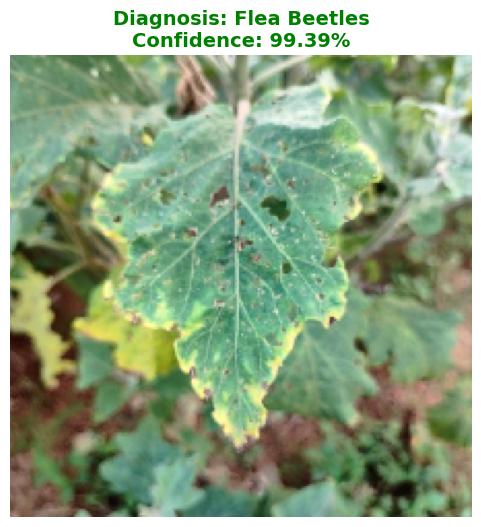

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("🚀 Waking up the 96.7% Champion Brain...")

# 1. Load the complete supercharged model
champion_model = tf.keras.models.load_model("DenseNet_PRO_Brinjal_Engine_Best.h5")

# 2. Rebuild the exact class names list
DATA_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Train'
class_names = sorted(os.listdir(DATA_DIR))

def test_blind_leaf(img_path):
    print(f"🔍 Analyzing: {img_path}")
    
    # Load and format the image
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, 0) 
    
    # Predict
    predictions = champion_model.predict(img_array, verbose=0)
    
    # Calculate Confidence
    predicted_index = np.argmax(predictions[0])
    predicted_label = class_names[predicted_index]
    confidence = 100 * np.max(predictions[0])
    
    # --- The Confidence Bouncer ---
    if confidence >= 75.0:
        display_text = f"Diagnosis: {predicted_label}\nConfidence: {confidence:.2f}%"
        color = 'green'
    else:
        display_text = f"⚠️ ERROR: Unrecognized Image.\n(Confidence only {confidence:.2f}%)"
        color = 'red'
        
    # Visual Output
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(display_text, color=color, fontweight='bold', fontsize=14)
    plt.axis('off')
    plt.show()

# ⚠️ PASTE YOUR COPIED BLIND SET PATH INSIDE THE QUOTES BELOW ⚠️
# Reminder: Go to your Blind_Set folder, Shift + Right-Click an image, and "Copy as path"
TEST_IMAGE_PATH = r"D:\Mini\Brinjal_Dataset_Project\MODEL_READY_DATA\Blind_Set\Flea Beetles\brinjal_25058.jpg"


test_blind_leaf(TEST_IMAGE_PATH)

In [9]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization

print("📱 Forging the MobileNetV2 Blueprint...")

# 1. Load the MobileNetV2 Core (Pre-trained on ImageNet)
base_mobilenet = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# 2. Freeze the core brain (Phase 1: Train only the top layer)
base_mobilenet.trainable = False

# 3. Build our Custom Brinjal Classification Head
x = base_mobilenet.output
x = GlobalAveragePooling2D()(x)

# Adding a moderate memory block (256 neurons) to help it handle the 37 classes
x = Dense(256, activation='relu')(x) 
x = BatchNormalization()(x)
x = Dropout(0.3)(x) 

predictions = Dense(37, activation='softmax')(x)

# 4. Assemble the final engine
mobilenet_model = Model(inputs=base_mobilenet.input, outputs=predictions)

# 5. Compile the model
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Setup Safety Nets (Watching val_accuracy from the start!)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=3, 
    restore_best_weights=True
)

mobilenet_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="MobileNetV2_Brinjal_Engine_Phase1.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("\n🚀 IGNITING MOBILENET PHASE 1: High-Speed Frozen Training...")

# 7. Start the initial training (15 rounds)
history_mobilenet_p1 = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stop, mobilenet_checkpoint]
)

📱 Forging the MobileNetV2 Blueprint...

🚀 IGNITING MOBILENET PHASE 1: High-Speed Frozen Training...
Epoch 1/15
4857/4857 [==============================] - ETA: 0s - loss: 1.4890 - accuracy: 0.4986
Epoch 1: val_accuracy improved from -inf to 0.59604, saving model to MobileNetV2_Brinjal_Engine_Phase1.h5
4857/4857 [==============================] - 202s 41ms/step - loss: 1.4890 - accuracy: 0.4986 - val_loss: 1.0873 - val_accuracy: 0.5960
Epoch 2/15
4856/4857 [============================>.] - ETA: 0s - loss: 1.2103 - accuracy: 0.5681
Epoch 2: val_accuracy improved from 0.59604 to 0.60901, saving model to MobileNetV2_Brinjal_Engine_Phase1.h5
4857/4857 [==============================] - 192s 40ms/step - loss: 1.2104 - accuracy: 0.5681 - val_loss: 1.0701 - val_accuracy: 0.6090
Epoch 3/15
4856/4857 [============================>.] - ETA: 0s - loss: 1.1610 - accuracy: 0.5863
Epoch 3: val_accuracy improved from 0.60901 to 0.62234, saving model to MobileNetV2_Brinjal_Engine_Phase1.h5
4857/4857 

In [12]:
print("🔓 UNFREEZING MOBILENET FOR DEEP LEARNING...")

# 1. Unfreeze the entire base model 
base_mobilenet.trainable = True

# 2. Re-compile with an extremely microscopic learning rate
# We use a tiny rate so we don't blow out MobileNet's delicate pre-trained weights
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. ALIGNED Safety Nets! (Watching val_accuracy)
early_stop_aligned = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=4, 
    restore_best_weights=True
)

mobilenet_finetune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="MobileNetV2_Brinjal_Engine_FINETUNED_Best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# 4. Dynamic Learning Rate
lr_reduction = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    patience=2,  
    factor=0.5,  
    min_lr=0.0000001,
    verbose=1
)

print("\n🚀 IGNITING MOBILENET PHASE 2: Deep Fine-Tuning...")

# 5. Run the fine-tuning loop for 20 rounds
history_mobilenet_finetune = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop_aligned, mobilenet_finetune_checkpoint, lr_reduction]
)

🔓 UNFREEZING MOBILENET FOR DEEP LEARNING...

🚀 IGNITING MOBILENET PHASE 2: Deep Fine-Tuning...
Epoch 1/20
4857/4857 [==============================] - ETA: 0s - loss: 2.0072 - accuracy: 0.3910
Epoch 1: val_accuracy improved from -inf to 0.62919, saving model to MobileNetV2_Brinjal_Engine_FINETUNED_Best.h5
4857/4857 [==============================] - 377s 76ms/step - loss: 2.0072 - accuracy: 0.3910 - val_loss: 1.0722 - val_accuracy: 0.6292 - lr: 1.0000e-05
Epoch 2/20
4857/4857 [==============================] - ETA: 0s - loss: 1.1394 - accuracy: 0.5944
Epoch 2: val_accuracy improved from 0.62919 to 0.71964, saving model to MobileNetV2_Brinjal_Engine_FINETUNED_Best.h5
4857/4857 [==============================] - 362s 75ms/step - loss: 1.1394 - accuracy: 0.5944 - val_loss: 0.7747 - val_accuracy: 0.7196 - lr: 1.0000e-05
Epoch 3/20
4857/4857 [==============================] - ETA: 0s - loss: 0.9223 - accuracy: 0.6717
Epoch 3: val_accuracy improved from 0.71964 to 0.76865, saving model to Mo

In [13]:
import tensorflow as tf

print("⚖️ Waking the Speedster for the Final Audit...")

# 1. Load the fine-tuned MobileNetV2 model
mobilenet_champion = tf.keras.models.load_model("MobileNetV2_Brinjal_Engine_FINETUNED_Best.h5")

# 2. Point to your reserved Test Set folder
TEST_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Test' 

print(f"\n📂 Loading Blind Test Data from: {TEST_DIR}")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode='categorical', # Using our fix from last time!
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print("\n🚀 Commencing Final Batch Evaluation...")

# 3. Grade the Model
loss, test_accuracy = mobilenet_champion.evaluate(test_dataset)

# 4. Print the Official Certificate
print("\n" + "="*50)
print("📱 MOBILENETV2: OFFICIAL FINAL SCORES 📱")
print("="*50)
print(f"✅ FINAL TEST ACCURACY : {test_accuracy * 100:.2f}%")
print(f"📉 FINAL TEST LOSS     : {loss:.4f}")
print("="*50)

⚖️ Waking the Speedster for the Final Audit...

📂 Loading Blind Test Data from: Brinjal_Dataset_Project\MODEL_READY_DATA\Test
Found 5550 files belonging to 37 classes.

🚀 Commencing Final Batch Evaluation...
174/174 [==============================] - 15s 76ms/step - loss: 0.2526 - accuracy: 0.9121

📱 MOBILENETV2: OFFICIAL FINAL SCORES 📱
✅ FINAL TEST ACCURACY : 91.21%
📉 FINAL TEST LOSS     : 0.2526


🚀 Waking up the Lightweight Speedster...
🔍 Analyzing: D:\Mini\Brinjal_Dataset_Project\MODEL_READY_DATA\Blind_Set\Wilt Disease\brinjal_20260.jpg


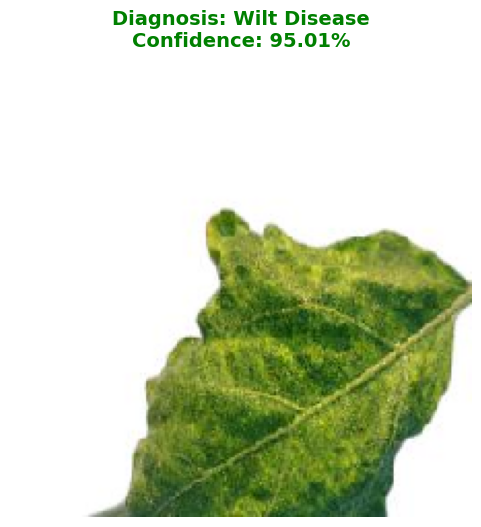

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("🚀 Waking up the Lightweight Speedster...")

# 1. Load the fine-tuned MobileNetV2 model
mobilenet_champion = tf.keras.models.load_model("MobileNetV2_Brinjal_Engine_FINETUNED_Best.h5")

# 2. Rebuild the exact class names list
DATA_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Train'
class_names = sorted(os.listdir(DATA_DIR))

def test_blind_leaf_mobilenet(img_path):
    print(f"🔍 Analyzing: {img_path}")
    
    # Load and format the image
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, 0) 
    
    # Predict
    predictions = mobilenet_champion.predict(img_array, verbose=0)
    
    # Calculate Confidence
    predicted_index = np.argmax(predictions[0])
    predicted_label = class_names[predicted_index]
    confidence = 100 * np.max(predictions[0])
    
    # --- The Confidence Bouncer ---
    if confidence >= 75.0:
        display_text = f"Diagnosis: {predicted_label}\nConfidence: {confidence:.2f}%"
        color = 'green'
    else:
        display_text = f"⚠️ ERROR: Unrecognized Image.\n(Confidence only {confidence:.2f}%)"
        color = 'red'
        
    # Visual Output
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(display_text, color=color, fontweight='bold', fontsize=14)
    plt.axis('off')
    plt.show()

# ⚠️ PASTE YOUR COPIED BLIND SET PATH INSIDE THE QUOTES BELOW ⚠️
# Reminder: Go to your Blind_Set folder, Shift + Right-Click an image, and "Copy as path"
TEST_IMAGE_PATH = r"D:\Mini\Brinjal_Dataset_Project\MODEL_READY_DATA\Blind_Set\Wilt Disease\brinjal_20260.jpg"

test_blind_leaf_mobilenet(TEST_IMAGE_PATH)

In [15]:
import os
import shutil
import random

print("📂 Initiating Data Transfer Protocol...")

# 1. Define your exact folder paths
# ⚠️ UPDATE THESE TO MATCH YOUR EXACT FOLDER LOCATIONS ⚠️
BLIND_SET_DIR = r"Brinjal_Dataset_Project\MODEL_READY_DATA\Blind_Set"
TEST_SET_DIR = r"Brinjal_Dataset_Project\MODEL_READY_DATA\Test"

# 2. Get the list of the 37 disease classes
classes = os.listdir(BLIND_SET_DIR)
total_moved = 0

for disease_class in classes:
    blind_class_path = os.path.join(BLIND_SET_DIR, disease_class)
    test_class_path = os.path.join(TEST_SET_DIR, disease_class)
    
    # Ensure the destination folder exists (it should, but just in case)
    os.makedirs(test_class_path, exist_ok=True)
    
    if os.path.isdir(blind_class_path):
        # Get all images currently in this specific Blind Set folder
        images = os.listdir(blind_class_path)
        
        # Calculate exactly one-third of these images (which equals 5% of total data)
        num_to_move = int(len(images) * (1/3))
        
        # Randomly select the images so we don't introduce bias
        images_to_move = random.sample(images, num_to_move)
        
        # Move them
        for img in images_to_move:
            src_path = os.path.join(blind_class_path, img)
            dest_path = os.path.join(test_class_path, img)
            shutil.move(src_path, dest_path)
            
        print(f"Moved {num_to_move} images for class: {disease_class}")
        total_moved += num_to_move

print("\n" + "="*50)
print(f"✅ TRANSFER COMPLETE! Successfully moved {total_moved} images.")
print("New Distribution: Test Set (15%) | Blind Set (10%)")
print("="*50)

📂 Initiating Data Transfer Protocol...
Moved 75 images for class: Aphids
Moved 75 images for class: Aphids_Purple
Moved 75 images for class: Aphids_White
Moved 75 images for class: Cercospora Leaf Spot
Moved 75 images for class: Cercospora Leaf Spot_Purple
Moved 75 images for class: Cercospora Leaf Spot_White
Moved 75 images for class: Flea Beetles
Moved 75 images for class: Flea Beetles_Purple
Moved 75 images for class: Flea Beetles_White
Moved 75 images for class: Healthy Leaf
Moved 75 images for class: Insect Pest Disease
Moved 75 images for class: Insect Pest Disease_Purple
Moved 75 images for class: Insect Pest Disease_White
Moved 75 images for class: Leaf Spot Disease
Moved 75 images for class: Leaf Spot Disease_Purple
Moved 75 images for class: Leaf Spot Disease_White
Moved 75 images for class: Leaf Wilt
Moved 75 images for class: Leaf Wilt_Purple
Moved 75 images for class: Leaf Wilt_White
Moved 75 images for class: Mosaic Virus Disease
Moved 75 images for class: Mosaic Virus Di

In [17]:
import os
import random
import shutil

# --- CONFIGURATION ---
SOURCE_DIR = r'Brinjal_Dataset_Project\FINAL_CATEGORIZED_DATA'
DEST_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA'

# The NEW Absolute Percentages
TRAIN_PCT = 0.70
VAL_PCT = 0.05
TEST_PCT = 0.15   # ⬆️ Increased to 15% for the mentor
BLIND_PCT = 0.10  # ⬇️ Decreased to 10%

# 🛡️ PROFESSIONAL SAFETY NET: Setting a seed for absolute reproducibility
random.seed(42)

# Define the 4 main folders
splits = ['Train', 'Validate', 'Test', 'Blind_Set']

print("📁 Building fresh directory structure...")
for split in splits:
    for category in os.listdir(SOURCE_DIR):
        if os.path.isdir(os.path.join(SOURCE_DIR, category)):
            os.makedirs(os.path.join(DEST_DIR, split, category), exist_ok=True)

print("🚀 Starting the 4-Way Data Split (70/5/15/10)...")

for folder in os.listdir(SOURCE_DIR):
    folder_path = os.path.join(SOURCE_DIR, folder)
    if not os.path.isdir(folder_path): continue

    # Get all images, SORT them first (crucial for reproducibility), then shuffle
    images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    images.sort() 
    random.shuffle(images)
    
    total_images = len(images)

    # Calculate exact numbers based on the TOTAL images
    train_count = int(total_images * TRAIN_PCT)
    val_count = int(total_images * VAL_PCT)
    blind_count = int(total_images * BLIND_PCT)

    # Test gets whatever is left over to ensure no image is lost to rounding decimals
    test_count = total_images - train_count - val_count - blind_count

    # Slice the shuffled list into our 4 chunks
    train_images = images[:train_count]
    val_images = images[train_count : train_count+val_count]
    test_images = images[train_count+val_count : train_count+val_count+test_count]
    blind_images = images[train_count+val_count+test_count:]

    print(f"📦 Routing '{folder}': Train({len(train_images)}) | Val({len(val_images)}) | Test({len(test_images)}) | Blind({len(blind_images)})")

    # Function to physically copy the files
    def copy_files(file_list, split_name):
        for img_name in file_list:
            src = os.path.join(folder_path, img_name)
            dst = os.path.join(DEST_DIR, split_name, folder, img_name)
            shutil.copy(src, dst)

    # Execute the copying to the new folders
    copy_files(train_images, 'Train')
    copy_files(val_images, 'Validate')
    copy_files(test_images, 'Test')
    copy_files(blind_images, 'Blind_Set')

print("\n✅ DATASET SPLIT COMPLETE! Your new 70/5/15/10 distribution is locked in.")

📁 Building fresh directory structure...
🚀 Starting the 4-Way Data Split (70/5/15/10)...
📦 Routing 'Aphids': Train(1050) | Val(75) | Test(225) | Blind(150)
📦 Routing 'Aphids_Purple': Train(1050) | Val(75) | Test(225) | Blind(150)
📦 Routing 'Aphids_White': Train(1050) | Val(75) | Test(225) | Blind(150)
📦 Routing 'Cercospora Leaf Spot': Train(1050) | Val(75) | Test(225) | Blind(150)
📦 Routing 'Cercospora Leaf Spot_Purple': Train(1050) | Val(75) | Test(225) | Blind(150)
📦 Routing 'Cercospora Leaf Spot_White': Train(1050) | Val(75) | Test(225) | Blind(150)
📦 Routing 'Flea Beetles': Train(1050) | Val(75) | Test(225) | Blind(150)
📦 Routing 'Flea Beetles_Purple': Train(1050) | Val(75) | Test(225) | Blind(150)
📦 Routing 'Flea Beetles_White': Train(1050) | Val(75) | Test(225) | Blind(150)
📦 Routing 'Healthy Leaf': Train(1050) | Val(75) | Test(225) | Blind(150)
📦 Routing 'Insect Pest Disease': Train(1050) | Val(75) | Test(225) | Blind(150)
📦 Routing 'Insect Pest Disease_Purple': Train(1050) | Val

In [19]:
import tensorflow as tf
import time

print("🏟️ INITIATING THE ULTIMATE AI SHOWDOWN...")

# 1. Point to your perfectly isolated 5% Validation Set
VAL_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Validate' 

print(f"\n📂 Loading Validation Data from: {VAL_DIR}")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    label_mode='categorical', # Our required 37-checkbox fix
    image_size=(224, 224),
    batch_size=32,
    shuffle=False # No shuffling so they all take the exact same test in the exact same order
)

# 2. Define the Roster of Champions
# Make sure these filenames perfectly match what is on your hard drive!
model_roster = {
    "DenseNet Pro (The Genius)": "DenseNet_PRO_Brinjal_Engine_Best.h5",
    "ResNet50 (The Heavyweight)": "ResNet50_Brinjal_Engine_FINETUNED_Best.h5",
    "MobileNetV2 (The Speedster)": "MobileNetV2_Brinjal_Engine_FINETUNED_Best.h5"
}

# Dictionary to store the final grades
results_board = {}

# 3. Run the Gauntlet
for model_name, model_path in model_roster.items():
    print("\n" + "-"*50)
    print(f"⚙️ Waking up: {model_name}...")
    
    # Load the specific brain
    current_model = tf.keras.models.load_model(model_path)
    
    print(f"📊 Grading {model_name} on the 5% Validation Vault...")
    start_time = time.time()
    
    # Run the evaluation
    loss, accuracy = current_model.evaluate(val_dataset, verbose=1)
    
    end_time = time.time()
    evaluation_time = end_time - start_time
    
    # Store the results
    results_board[model_name] = {
        "Accuracy": accuracy * 100,
        "Loss": loss,
        "Time": evaluation_time
    }
    
    # Clear the model from GPU memory before loading the next one to prevent crashing
    tf.keras.backend.clear_session()

# 4. Print the Official Leaderboard
print("\n\n" + "="*70)
print("🏆 OFFICIAL VALIDATION LEADERBOARD 🏆")
print("="*70)
print(f"{'Model Architecture':<30} | {'Accuracy':<10} | {'Loss':<10} | {'Eval Time':<10}")
print("-" * 70)

for name, metrics in results_board.items():
    acc_str = f"{metrics['Accuracy']:.2f}%"
    loss_str = f"{metrics['Loss']:.4f}"
    time_str = f"{metrics['Time']:.1f} sec"
    print(f"{name:<30} | {acc_str:<10} | {loss_str:<10} | {time_str:<10}")

print("="*70)


🏟️ INITIATING THE ULTIMATE AI SHOWDOWN...

📂 Loading Validation Data from: Brinjal_Dataset_Project\MODEL_READY_DATA\Validate
Found 2775 files belonging to 37 classes.

--------------------------------------------------
⚙️ Waking up: DenseNet Pro (The Genius)...
📊 Grading DenseNet Pro (The Genius) on the 5% Validation Vault...
87/87 [==============================] - 22s 217ms/step - loss: 0.0447 - accuracy: 0.9921

--------------------------------------------------
⚙️ Waking up: ResNet50 (The Heavyweight)...
📊 Grading ResNet50 (The Heavyweight) on the 5% Validation Vault...
87/87 [==============================] - 15s 149ms/step - loss: 0.1005 - accuracy: 0.9766

--------------------------------------------------
⚙️ Waking up: MobileNetV2 (The Speedster)...
📊 Grading MobileNetV2 (The Speedster) on the 5% Validation Vault...
87/87 [==============================] - 8s 72ms/step - loss: 0.1373 - accuracy: 0.9589


🏆 OFFICIAL VALIDATION LEADERBOARD 🏆
Model Architecture             | Accur

In [20]:
import tensorflow as tf
import time

print("⚖️ INITIATING FINAL A/B/C TESTING ON THE 15% VAULT...")

# 1. Point to your 15% Test Set
TEST_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Test' 

print(f"\n📂 Loading Official Test Data from: {TEST_DIR}")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode='categorical', # Our required 37-checkbox fix
    image_size=(224, 224),
    batch_size=32,
    shuffle=False # No shuffling so they all take the exact same test in the exact same order
)

# 2. Define the Roster of Champions
model_roster = {
    "DenseNet Pro (The Genius)": "DenseNet_PRO_Brinjal_Engine_Best.h5",
    "ResNet50 (The Heavyweight)": "ResNet50_Brinjal_Engine_FINETUNED_Best.h5",
    "MobileNetV2 (The Speedster)": "MobileNetV2_Brinjal_Engine_FINETUNED_Best.h5"
}

# Dictionary to store the final grades
results_board = {}

# 3. Run the Gauntlet
for model_name, model_path in model_roster.items():
    print("\n" + "-"*50)
    print(f"⚙️ Waking up: {model_name}...")
    
    # Load the specific brain
    current_model = tf.keras.models.load_model(model_path)
    
    print(f"📊 Grading {model_name} on the 15% Test Vault...")
    start_time = time.time()
    
    # Run the evaluation
    loss, accuracy = current_model.evaluate(test_dataset, verbose=1)
    
    end_time = time.time()
    evaluation_time = end_time - start_time
    
    # Store the results
    results_board[model_name] = {
        "Accuracy": accuracy * 100,
        "Loss": loss,
        "Time": evaluation_time
    }
    
    # Clear the model from GPU memory before loading the next one to prevent crashing
    tf.keras.backend.clear_session()

# 4. Print the Official Leaderboard
print("\n\n" + "="*70)
print("🏆 OFFICIAL 15% TEST LEADERBOARD 🏆")
print("="*70)
print(f"{'Model Architecture':<30} | {'Accuracy':<10} | {'Loss':<10} | {'Eval Time':<10}")
print("-" * 70)

for name, metrics in results_board.items():
    acc_str = f"{metrics['Accuracy']:.2f}%"
    loss_str = f"{metrics['Loss']:.4f}"
    time_str = f"{metrics['Time']:.1f} sec"
    print(f"{name:<30} | {acc_str:<10} | {loss_str:<10} | {time_str:<10}")

print("="*70)


⚖️ INITIATING FINAL A/B/C TESTING ON THE 15% VAULT...

📂 Loading Official Test Data from: Brinjal_Dataset_Project\MODEL_READY_DATA\Test
Found 8325 files belonging to 37 classes.

--------------------------------------------------
⚙️ Waking up: DenseNet Pro (The Genius)...
📊 Grading DenseNet Pro (The Genius) on the 15% Test Vault...
261/261 [==============================] - 58s 212ms/step - loss: 0.0459 - accuracy: 0.9900

--------------------------------------------------
⚙️ Waking up: ResNet50 (The Heavyweight)...
📊 Grading ResNet50 (The Heavyweight) on the 15% Test Vault...
261/261 [==============================] - 42s 155ms/step - loss: 0.0969 - accuracy: 0.9761

--------------------------------------------------
⚙️ Waking up: MobileNetV2 (The Speedster)...
📊 Grading MobileNetV2 (The Speedster) on the 15% Test Vault...
261/261 [==============================] - 21s 74ms/step - loss: 0.1353 - accuracy: 0.9518


🏆 OFFICIAL 15% TEST LEADERBOARD 🏆
Model Architecture             | Accu

In [21]:
import os
import shutil

print("🚚 Initiating Validate-to-Train Merge Protocol...")

# 1. Define your exact folder paths
VALIDATE_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Validate'
TRAIN_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Train'

total_moved = 0

# 2. Get the list of the 37 disease classes
if os.path.exists(VALIDATE_DIR):
    classes = os.listdir(VALIDATE_DIR)

    for disease_class in classes:
        val_class_path = os.path.join(VALIDATE_DIR, disease_class)
        train_class_path = os.path.join(TRAIN_DIR, disease_class)
        
        # Ensure the destination Train folder exists
        os.makedirs(train_class_path, exist_ok=True)
        
        if os.path.isdir(val_class_path):
            images = os.listdir(val_class_path)
            
            # Move every image from Validate to Train
            for img in images:
                src_path = os.path.join(val_class_path, img)
                dest_path = os.path.join(train_class_path, img)
                shutil.move(src_path, dest_path)
                total_moved += 1
                
            # Clean up the now-empty class folder inside Validate
            os.rmdir(val_class_path)

    # 3. Destroy the main Validate folder
    os.rmdir(VALIDATE_DIR)

    print("\n" + "="*60)
    print(f"✅ MERGE COMPLETE! Successfully moved {total_moved} images.")
    print("New Distribution: Train Set (75%) | Test Set (15%) | Blind Set (10%)")
    print("The 'Validate' folder has been securely deleted.")
    print("="*60)
else:
    print("⚠️ The Validate folder does not exist. It may have already been moved!")

🚚 Initiating Validate-to-Train Merge Protocol...

✅ MERGE COMPLETE! Successfully moved 2775 images.
New Distribution: Train Set (75%) | Test Set (15%) | Blind Set (10%)
The 'Validate' folder has been securely deleted.


In [22]:
import os
import shutil
import random

print("🔄 Initiating Blind-to-Validate Extraction Protocol...")

# 1. Define your exact folder paths
BLIND_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Blind_Set'
VALIDATE_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Validate'

# 🛡️ Safety Net: Ensures this random selection is perfectly reproducible
random.seed(42)

total_moved = 0

if os.path.exists(BLIND_DIR):
    classes = os.listdir(BLIND_DIR)
    
    for disease_class in classes:
        blind_class_path = os.path.join(BLIND_DIR, disease_class)
        val_class_path = os.path.join(VALIDATE_DIR, disease_class)
        
        # Ensure the new Validate folder exists for this specific disease
        os.makedirs(val_class_path, exist_ok=True)
        
        if os.path.isdir(blind_class_path):
            # Get the images and sort them to ensure the seed works correctly
            images = [f for f in os.listdir(blind_class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            images.sort()
            
            # Calculate exactly 50% of the current folder's contents
            num_to_move = int(len(images) * 0.50)
            
            # Randomly select the images
            images_to_move = random.sample(images, num_to_move)
            
            # Move them from Blind to Validate
            for img in images_to_move:
                src_path = os.path.join(blind_class_path, img)
                dest_path = os.path.join(val_class_path, img)
                shutil.move(src_path, dest_path)
                total_moved += 1
                
    print("\n" + "="*65)
    print(f"✅ EXTRACTION COMPLETE! Successfully moved {total_moved} images.")
    print("New Distribution: Train (75%) | Validate (5%) | Test (15%) | Blind (5%)")
    print("="*65)
else:
    print("⚠️ The Blind_Set folder could not be found. Check your file paths!")

🔄 Initiating Blind-to-Validate Extraction Protocol...

✅ EXTRACTION COMPLETE! Successfully moved 2775 images.
New Distribution: Train (75%) | Validate (5%) | Test (15%) | Blind (5%)


In [24]:
!pip install scikit-learn


   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ------------ --------------------------- 2.9/8.9 MB 13.9 MB/s eta 0:00:01
   ----------------------- ---------------- 5.2/8.9 MB 12.7 MB/s eta 0:00:01
   ---------------------------------- ----- 7.6/8.9 MB 12.0 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 10.6 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   ----------------

🔬 INITIATING MASTER STATISTICAL VALIDATION SUITE...

📂 Loading Validation Data from: Brinjal_Dataset_Project\MODEL_READY_DATA\Validate
Found 2775 files belonging to 37 classes.

📥 Extracting True Real-World Labels...

⚙️ EXAMINING: DenseNet Pro (The Genius)
🤖 DenseNet Pro (The Genius) is diagnosing the Validation Set...
87/87 [==============================] - 20s 170ms/step

📄 CLASSIFICATION REPORT (Precision/Recall/F1-Score):
                             precision    recall  f1-score   support

                     Aphids       1.00      1.00      1.00        75
              Aphids_Purple       1.00      1.00      1.00        75
               Aphids_White       1.00      1.00      1.00        75
       Cercospora Leaf Spot       1.00      1.00      1.00        75
Cercospora Leaf Spot_Purple       1.00      1.00      1.00        75
 Cercospora Leaf Spot_White       1.00      1.00      1.00        75
               Flea Beetles       1.00      1.00      1.00        75
        Flea Be

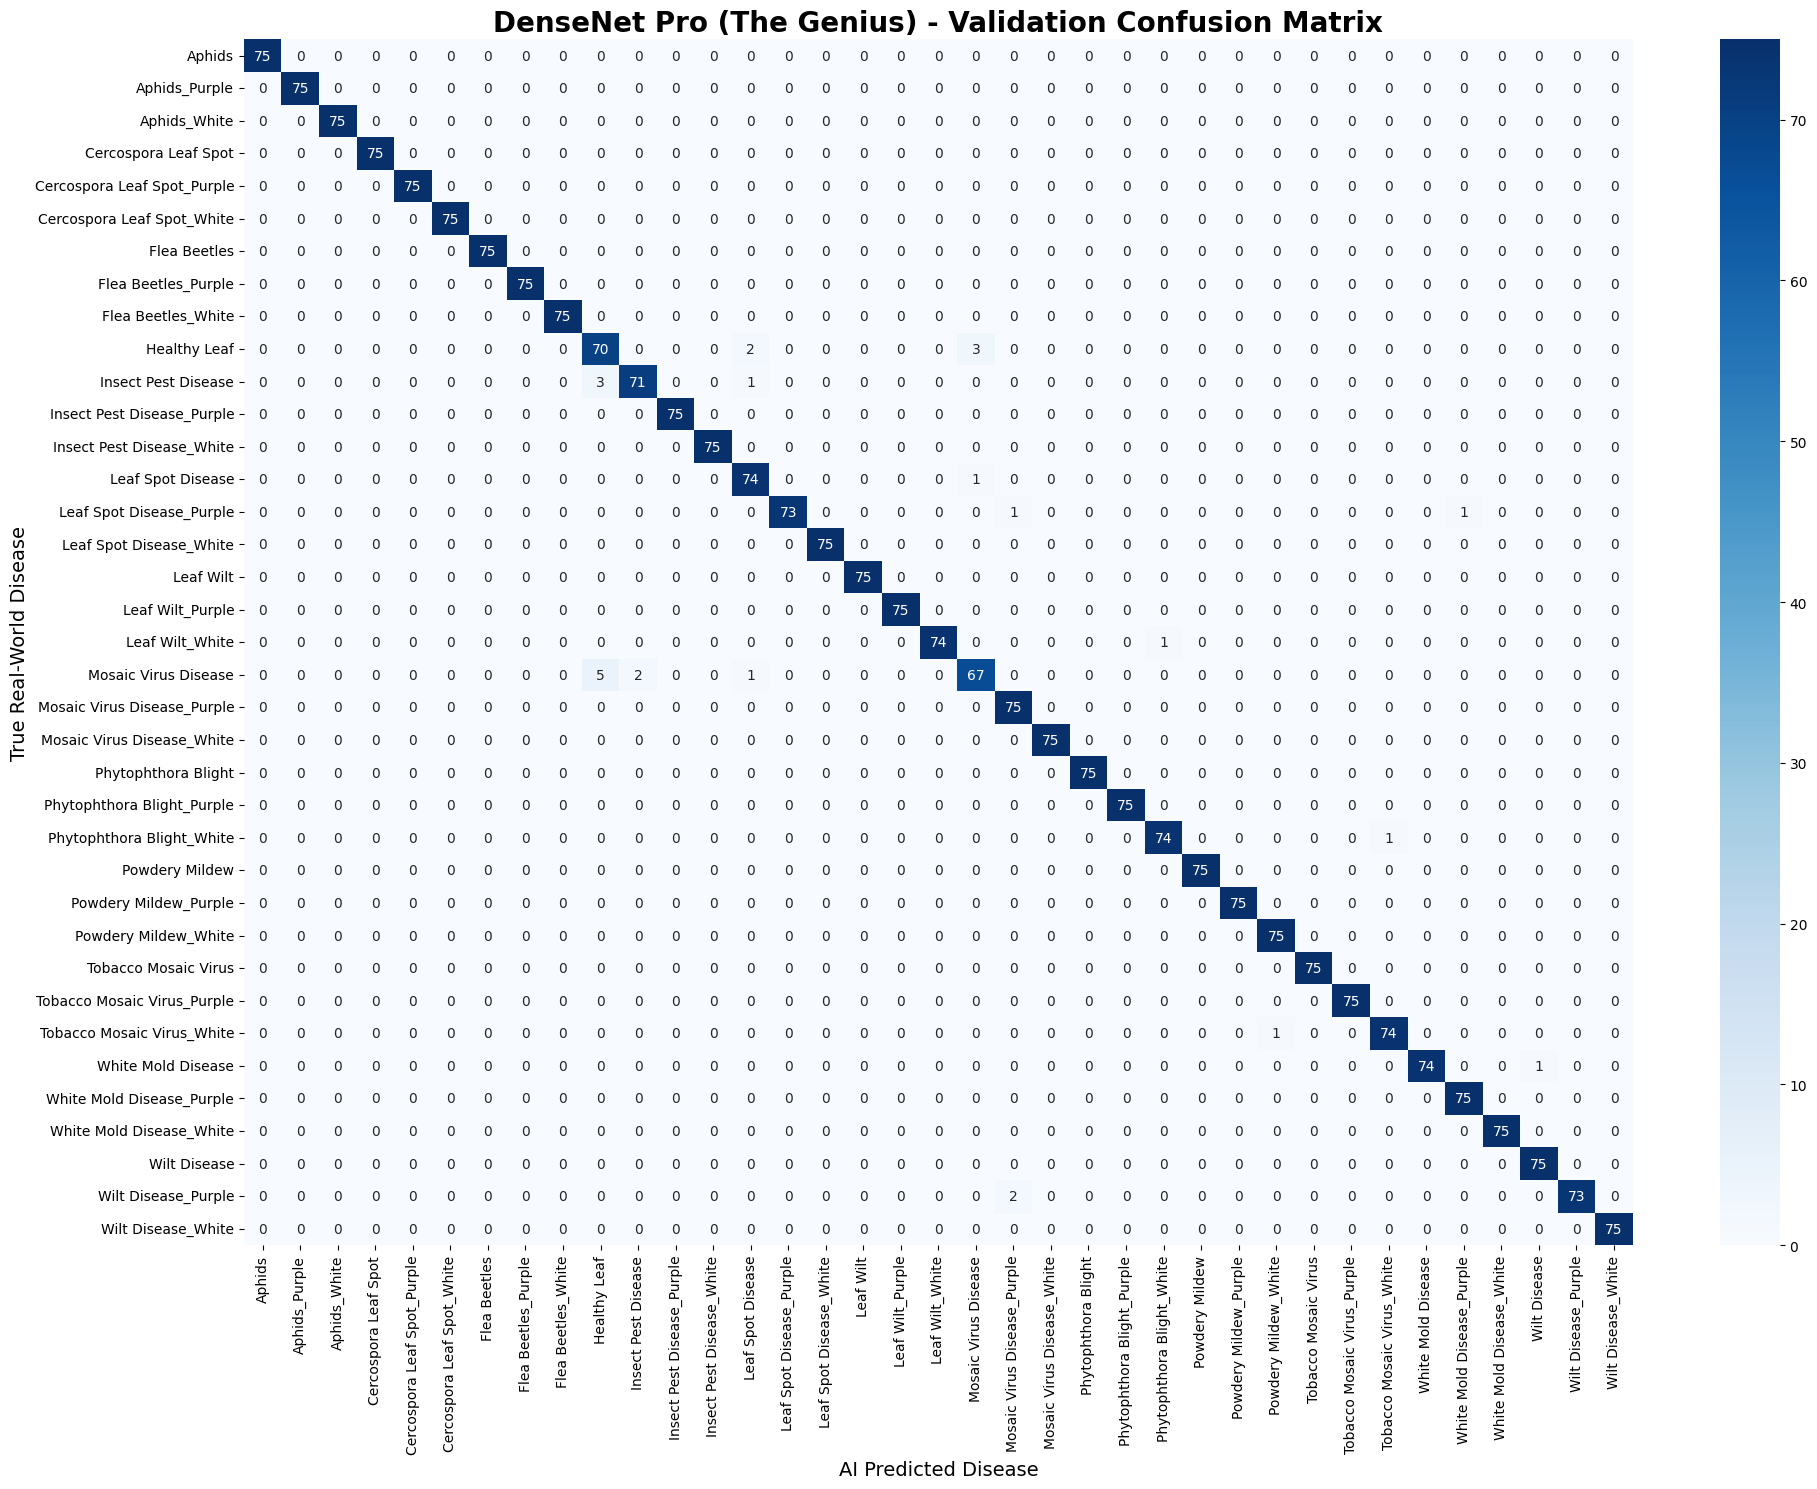


⚙️ EXAMINING: ResNet50 (The Heavyweight)
🤖 ResNet50 (The Heavyweight) is diagnosing the Validation Set...
87/87 [==============================] - 13s 124ms/step

📄 CLASSIFICATION REPORT (Precision/Recall/F1-Score):
                             precision    recall  f1-score   support

                     Aphids       1.00      0.99      0.99        75
              Aphids_Purple       1.00      1.00      1.00        75
               Aphids_White       1.00      0.99      0.99        75
       Cercospora Leaf Spot       1.00      1.00      1.00        75
Cercospora Leaf Spot_Purple       1.00      0.96      0.98        75
 Cercospora Leaf Spot_White       1.00      1.00      1.00        75
               Flea Beetles       1.00      1.00      1.00        75
        Flea Beetles_Purple       1.00      1.00      1.00        75
         Flea Beetles_White       1.00      1.00      1.00        75
               Healthy Leaf       0.86      0.93      0.90        75
        Insect Pest Dis

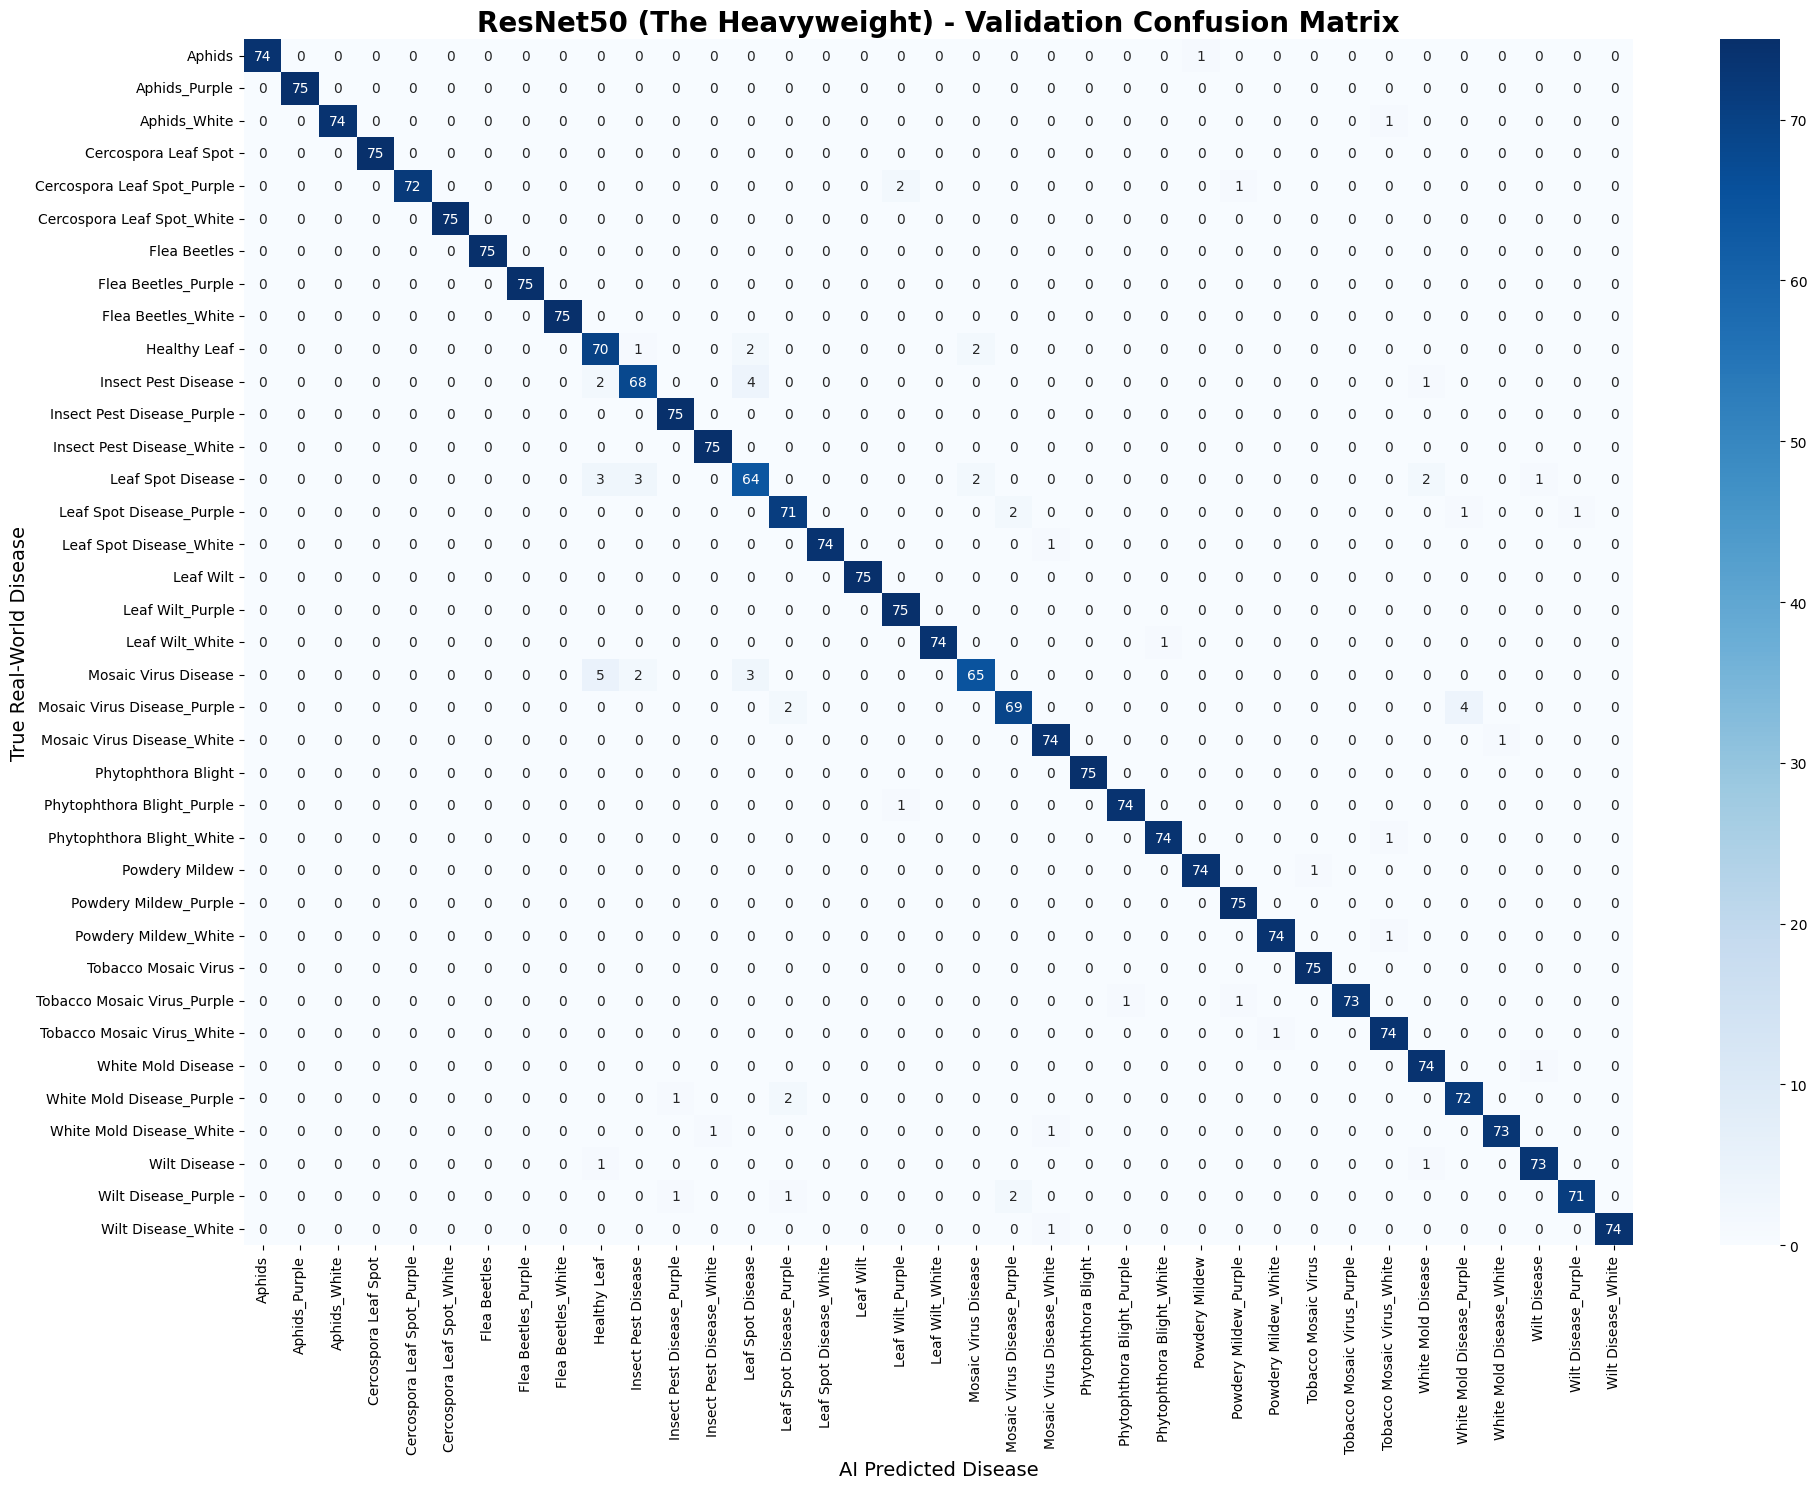


⚙️ EXAMINING: MobileNetV2 (The Speedster)
🤖 MobileNetV2 (The Speedster) is diagnosing the Validation Set...
87/87 [==============================] - 8s 79ms/step

📄 CLASSIFICATION REPORT (Precision/Recall/F1-Score):
                             precision    recall  f1-score   support

                     Aphids       0.95      1.00      0.97        75
              Aphids_Purple       0.97      0.99      0.98        75
               Aphids_White       1.00      0.97      0.99        75
       Cercospora Leaf Spot       1.00      1.00      1.00        75
Cercospora Leaf Spot_Purple       1.00      0.99      0.99        75
 Cercospora Leaf Spot_White       0.99      0.97      0.98        75
               Flea Beetles       1.00      0.97      0.99        75
        Flea Beetles_Purple       0.99      0.99      0.99        75
         Flea Beetles_White       1.00      1.00      1.00        75
               Healthy Leaf       0.80      0.71      0.75        75
        Insect Pest Dis

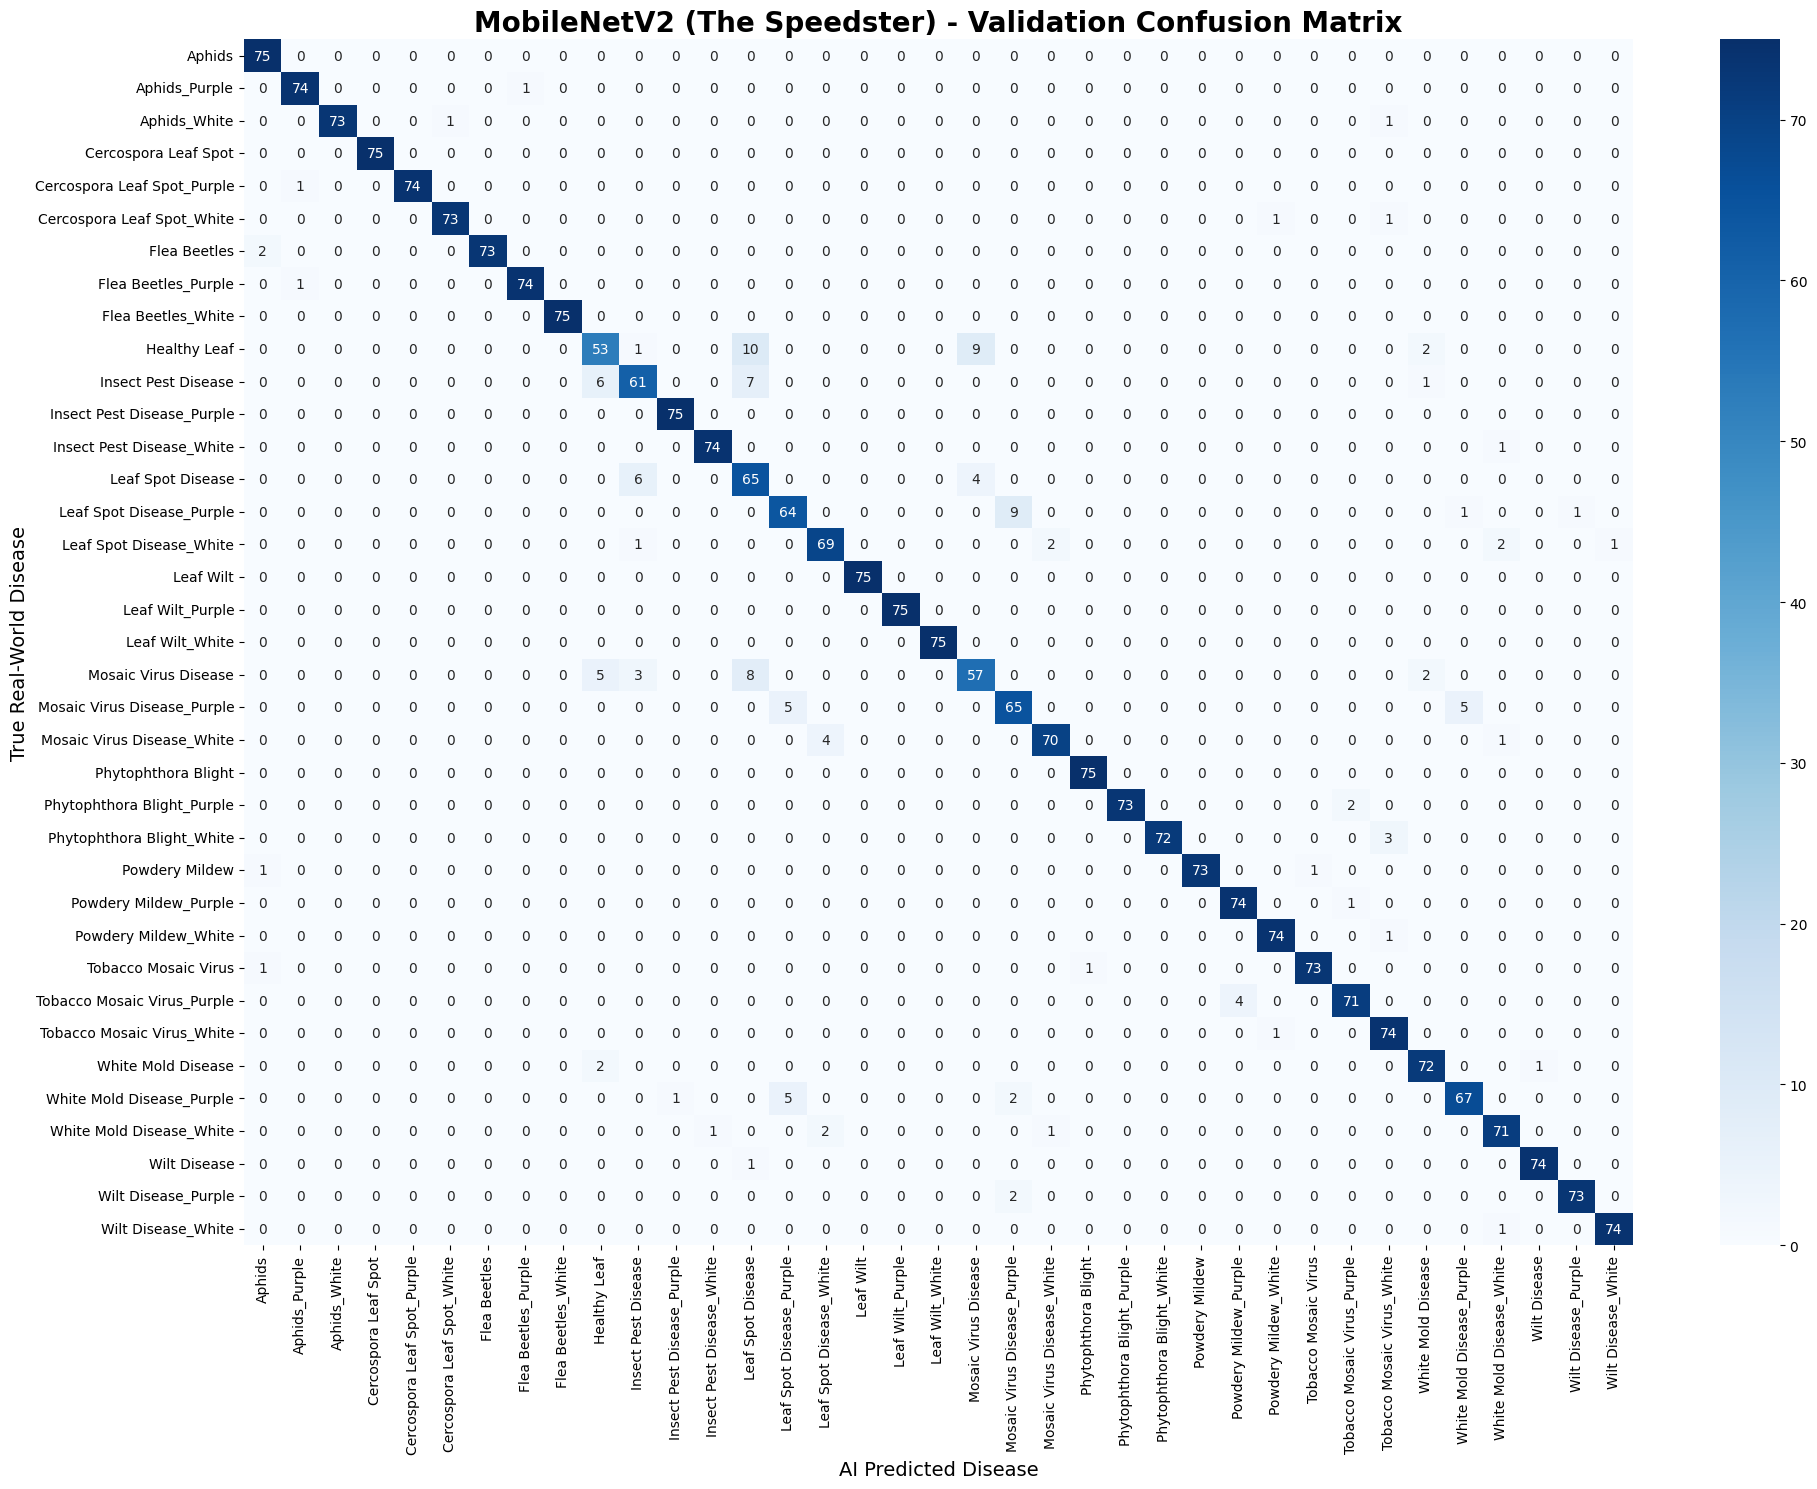


✅ MASTER VALIDATION SUITE COMPLETE!


In [25]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

print("🔬 INITIATING MASTER STATISTICAL VALIDATION SUITE...")

# 1. Point to your newly created 5% Validate Vault
VALIDATE_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Validate' 

print(f"\n📂 Loading Validation Data from: {VALIDATE_DIR}")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VALIDATE_DIR,
    label_mode='categorical',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False # CRITICAL: No shuffling so predictions perfectly match the true labels!
)

# Get the exact 37 class names
class_names = val_dataset.class_names

print("\n📥 Extracting True Real-World Labels...")
# We only need to extract the true answers once, as all 3 models take the same test
true_labels = []
for images, labels in val_dataset:
    true_labels.extend(np.argmax(labels.numpy(), axis=1))

# 2. Define the Roster of Champions
model_roster = {
    "DenseNet Pro (The Genius)": "DenseNet_PRO_Brinjal_Engine_Best.h5",
    "ResNet50 (The Heavyweight)": "ResNet50_Brinjal_Engine_FINETUNED_Best.h5",
    "MobileNetV2 (The Speedster)": "MobileNetV2_Brinjal_Engine_FINETUNED_Best.h5"
}

# 3. Run the Deep Analysis Loop
for model_name, model_path in model_roster.items():
    print("\n" + "="*80)
    print(f"⚙️ EXAMINING: {model_name}")
    print("="*80)
    
    # Load the specific brain
    current_model = tf.keras.models.load_model(model_path)
    
    print(f"🤖 {model_name} is diagnosing the Validation Set...")
    predictions = current_model.predict(val_dataset, verbose=1)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Generate the Official Classification Report
    print(f"\n📄 CLASSIFICATION REPORT (Precision/Recall/F1-Score):")
    # zero_division=0 prevents warnings if a model totally fails to guess a certain class
    report = classification_report(true_labels, predicted_labels, target_names=class_names, zero_division=0)
    print(report)
    
    # Generate and Plot the Confusion Matrix Heatmap
    print(f"\n🗺️ Plotting Confusion Matrix for {model_name}...")
    cm = confusion_matrix(true_labels, predicted_labels)
    
    plt.figure(figsize=(20, 15)) # Massive canvas to fit all 37 classes
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title(f'{model_name} - Validation Confusion Matrix', fontsize=20, fontweight='bold')
    plt.ylabel('True Real-World Disease', fontsize=14)
    plt.xlabel('AI Predicted Disease', fontsize=14)
    plt.xticks(rotation=90) # Rotate the labels so they are readable
    plt.tight_layout()
    plt.show() # Display the graph before moving to the next model
    
    # 🛡️ Clear the model from GPU memory to prevent your laptop from crashing
    tf.keras.backend.clear_session()

print("\n✅ MASTER VALIDATION SUITE COMPLETE!")

In [27]:
try:
    # Replace 'history' with whatever you named your variable during model.fit()
    # Common names: history, history_densenet, phase2_history
    print(history_fine.history.keys())
    print("✅ SUCCESS! The memory is still alive. You can run the graphing script!")
except NameError:
    print("❌ AMNESIA! The kernel restarted and the training history is gone.")

❌ AMNESIA! The kernel restarted and the training history is gone.


In [28]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
import os

print("🛫 Initiating Authentic Re-Run with Black Box Recording...")

# 1. Point to your 75% Train and 5% Validate sets
TRAIN_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Train'
VAL_DIR = r'Brinjal_Dataset_Project\MODEL_READY_DATA\Validate'

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, label_mode='categorical', image_size=(224, 224), batch_size=32)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, label_mode='categorical', image_size=(224, 224), batch_size=32)

# 2. Re-build the DenseNet Pro Architecture (from scratch)
base_model = tf.keras.applications.DenseNet121(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Start frozen

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(512, activation='relu')(x) # The Pro Memory Block
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)
predictions = tf.keras.layers.Dense(37, activation='softmax')(x)

graph_model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)

graph_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. 🛡️ THE BLACK BOX RECORDER 🛡️
# This saves the history to a file that survives computer restarts!
csv_logger = CSVLogger('DenseNet_Training_History.csv', append=True)

early_stop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)

print("\n🚀 Starting Phase 1 Training (Recording to CSV...)")
# Running for 15 epochs max (Early stopping might catch it sooner)
history = graph_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stop, csv_logger]
)

print("\n✅ Run Complete! The Black Box 'DenseNet_Training_History.csv' is safely saved to your hard drive.")

🛫 Initiating Authentic Re-Run with Black Box Recording...
Found 41625 files belonging to 37 classes.
Found 2775 files belonging to 37 classes.

🚀 Starting Phase 1 Training (Recording to CSV...)
Epoch 1/15
1301/1301 [==============================] - 258s 189ms/step - loss: 1.1952 - accuracy: 0.5629 - val_loss: 0.9205 - val_accuracy: 0.6580
Epoch 2/15
1301/1301 [==============================] - 244s 187ms/step - loss: 0.9311 - accuracy: 0.6426 - val_loss: 0.8581 - val_accuracy: 0.6663
Epoch 3/15
1301/1301 [==============================] - 245s 187ms/step - loss: 0.8717 - accuracy: 0.6625 - val_loss: 0.8016 - val_accuracy: 0.6886
Epoch 4/15
1301/1301 [==============================] - 245s 188ms/step - loss: 0.8408 - accuracy: 0.6755 - val_loss: 0.7929 - val_accuracy: 0.6886
Epoch 5/15
1301/1301 [==============================] - 249s 191ms/step - loss: 0.8218 - accuracy: 0.6825 - val_loss: 0.7665 - val_accuracy: 0.6944
Epoch 6/15
1301/1301 [==============================] - 243s 186ms